In [1]:
import pandas as pd
print(pd.__version__)

2.3.3


In [2]:
import glob
import os

files = glob.glob("*_20.xlsx")

print("\nTotal files found:", len(files))


Total files found: 7


In [3]:
files = [f for f in glob.glob("*_20*.xlsx") if not f.startswith("US")]

In [4]:
print("\nFiles found:")
for file in files:
    print(file)


Files found:
Minneapolis_20.xlsx
Dallas_20.xlsx
Phoenix_20.xlsx
Chicago_20.xlsx
Atlanta_20.xlsx
Houston_20.xlsx


In [5]:
import pandas as pd
import glob
import os

# Step 1. Combine all metro files (excluding US)
metro_files = [f for f in glob.glob("*_20.xlsx") if not f.startswith("US")]

metros_combined = pd.DataFrame()

for file in metro_files:
    city = os.path.splitext(os.path.basename(file))[0].replace('_20', '')
    
    df = pd.read_excel(file)
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Period'], format='%Y-%b')
    
    df_city = df[['Date', 'unemployment rate']].copy()
    df_city.rename(columns={'unemployment rate': city}, inplace=True)
    
    if metros_combined.empty:
        metros_combined = df_city
    else:
        metros_combined = pd.merge(metros_combined, df_city, on='Date', how='outer')

metros_combined.sort_values('Date', inplace=True)
metros_combined.set_index('Date', inplace=True)
metros_combined = metros_combined.asfreq('MS')
print("✅ Metro data combined. Columns:", metros_combined.columns.tolist())

✅ Metro data combined. Columns: ['Minneapolis', 'Dallas', 'Phoenix', 'Chicago', 'Atlanta', 'Houston']


In [6]:
# Step 2. Read and reshape the US file
us_df = pd.read_excel("US_20.xlsx")

# Convert from wide months to long monthly rows
us_long = us_df.melt(id_vars='Year', var_name='Month', value_name='US')
us_long['Date'] = pd.to_datetime(us_long['Year'].astype(str) + '-' + us_long['Month'], format='%Y-%b')

us_long = us_long[['Date', 'US']]
us_long.sort_values('Date', inplace=True)
us_long.set_index('Date', inplace=True)
us_long = us_long.asfreq('MS')

print("✅ US data reshaped. Length:", len(us_long))

✅ US data reshaped. Length: 252


In [7]:
# --- Merge US with metros ---
final_combined = us_long.join(metros_combined, how='outer')

# --- Identify the true date range from actual data ---
min_date = final_combined.dropna(how='all').index.min()
max_date = final_combined.dropna(how='all').index.max()

# --- Clip to that range ---
final_combined = final_combined.loc[min_date:max_date]

# --- Sort and keep monthly start frequency ---
final_combined.sort_index(inplace=True)
final_combined = final_combined.asfreq('MS')

# --- Save combined file ---
final_combined.to_excel("Unrate_20.xlsx", index_label='Date')

print("✅ Final file saved as 'Unrate_20.xlsx'")
print("Final columns:", final_combined.columns.tolist())
print(f"Date range clipped from {min_date:%b-%Y} to {max_date:%b-%Y}")

✅ Final file saved as 'Unrate_20.xlsx'
Final columns: ['US', 'Minneapolis', 'Dallas', 'Phoenix', 'Chicago', 'Atlanta', 'Houston']
Date range clipped from Jan-2005 to Aug-2025


In [8]:
print(final_combined.head())

             US  Minneapolis  Dallas  Phoenix  Chicago  Atlanta  Houston
Date                                                                    
2005-01-01  5.3          4.4     5.9      4.2      6.5      5.4      6.1
2005-02-01  5.4          4.4     5.9      4.1      6.9      5.6      6.1
2005-03-01  5.2          4.4     5.3      4.1      6.5      5.3      5.5
2005-04-01  5.2          3.9     5.1      4.0      6.2      5.0      5.2
2005-05-01  5.1          3.6     5.1      3.9      6.0      5.3      5.3


In [9]:
final_combined.index = pd.to_datetime(final_combined.index)
final_combined = final_combined.asfreq('MS')

In [10]:
print(final_combined.index)
print(final_combined.head())

DatetimeIndex(['2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01',
               '2005-05-01', '2005-06-01', '2005-07-01', '2005-08-01',
               '2005-09-01', '2005-10-01',
               ...
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01'],
              dtype='datetime64[ns]', name='Date', length=248, freq='MS')
             US  Minneapolis  Dallas  Phoenix  Chicago  Atlanta  Houston
Date                                                                    
2005-01-01  5.3          4.4     5.9      4.2      6.5      5.4      6.1
2005-02-01  5.4          4.4     5.9      4.1      6.9      5.6      6.1
2005-03-01  5.2          4.4     5.3      4.1      6.5      5.3      5.5
2005-04-01  5.2          3.9     5.1      4.0      6.2      5.0      5.2
2005-05-01  5.1          3.6     5.1      3.9      6.0      5.3      5.3


In [11]:
import pandas as pd

cpi = pd.read_excel("CPI20.xlsx")

In [12]:
cpi.head()

,Date,CPI
0,2005-01-01,191.6
1,2005-02-01,192.4
2,2005-03-01,193.1
3,2005-04-01,193.7
4,2005-05-01,193.6


In [13]:
cpi['Date'] = pd.to_datetime(cpi['Date'])

In [14]:
# Set Date as index and ensure monthly frequency
cpi.set_index('Date', inplace=True)
cpi = cpi.asfreq('MS')   # 'MS' = month start frequency

In [15]:
cpi['Inflation_MoM'] = 100 * (cpi['CPI'] / cpi['CPI'].shift(1) - 1)

In [16]:
cpi.dropna(inplace=True)

In [17]:
import matplotlib.pyplot as plt

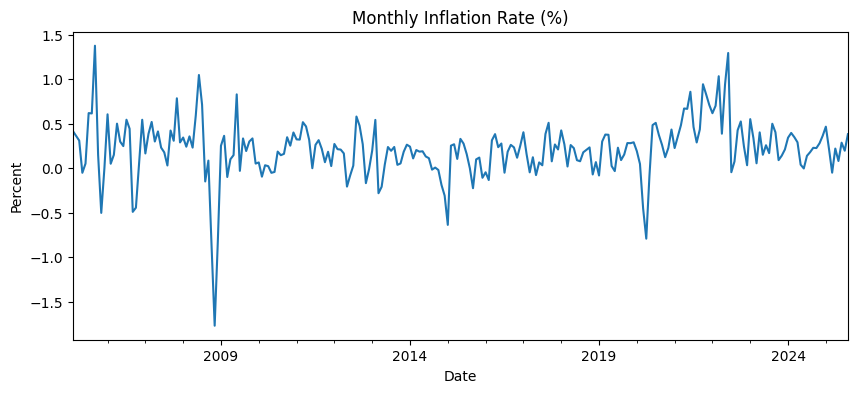

In [18]:
cpi['Inflation_MoM'].plot(figsize=(10,4), title="Monthly Inflation Rate (%)")
plt.ylabel("Percent")
plt.show()

In [19]:
cpi.head()

,CPI,Inflation_MoM
Date,,
2005-02-01,192.4,0.417537
2005-03-01,193.1,0.363825
2005-04-01,193.7,0.310720
2005-05-01,193.6,-0.051626
2005-06-01,193.7,0.051653


In [20]:
final_combined = final_combined.join(cpi[['CPI', 'Inflation_MoM']], how='inner')

In [21]:
final_combined.head()

,US,Minneapolis,Dallas,Phoenix,Chicago,Atlanta,Houston,CPI,Inflation_MoM
Date,,,,,,,,,
2005-02-01,5.4,4.4,5.9,4.1,6.9,5.6,6.1,192.4,0.417537
2005-03-01,5.2,4.4,5.3,4.1,6.5,5.3,5.5,193.1,0.363825
2005-04-01,5.2,3.9,5.1,4.0,6.2,5.0,5.2,193.7,0.310720
2005-05-01,5.1,3.6,5.1,3.9,6.0,5.3,5.3,193.6,-0.051626
2005-06-01,5.0,4.0,5.3,4.2,6.6,5.7,5.6,193.7,0.051653


In [22]:
print(final_combined.info())
print(final_combined.head())
print(final_combined.index.min(), "→", final_combined.index.max())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 247 entries, 2005-02-01 to 2025-08-01
Freq: MS
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   US             247 non-null    float64
 1   Minneapolis    247 non-null    float64
 2   Dallas         247 non-null    float64
 3   Phoenix        247 non-null    float64
 4   Chicago        247 non-null    float64
 5   Atlanta        247 non-null    float64
 6   Houston        247 non-null    float64
 7   CPI            247 non-null    float64
 8   Inflation_MoM  247 non-null    float64
dtypes: float64(9)
memory usage: 19.3 KB
None
             US  Minneapolis  Dallas  Phoenix  Chicago  Atlanta  Houston  \
Date                                                                       
2005-02-01  5.4          4.4     5.9      4.1      6.9      5.6      6.1   
2005-03-01  5.2          4.4     5.3      4.1      6.5      5.3      5.5   
2005-04-01  5.2          3.9     5

In [23]:
# Assuming your main dataframe is called final_combined
final_combined['Crisis_2008'] = (
    (final_combined.index >= '2008-09-01') &
    (final_combined.index <= '2010-06-01')
).astype(int)

final_combined['Crisis_2020'] = ((final_combined.index >= '2020-03-01') &
                                 (final_combined.index <= '2020-12-01')).astype(int)

<Axes: title={'center': 'US Unemployment and Crisis Dummies'}, xlabel='Date'>

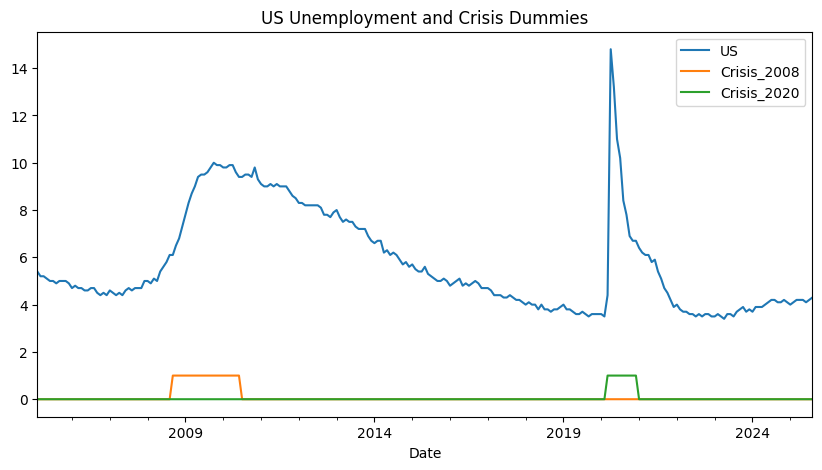

In [24]:
final_combined[['US', 'Crisis_2008', 'Crisis_2020']].plot(figsize=(10,5), title='US Unemployment and Crisis Dummies')

In [25]:
final_combined.head()

,US,Minneapolis,Dallas,Phoenix,Chicago,Atlanta,Houston,CPI,Inflation_MoM,Crisis_2008,Crisis_2020
Date,,,,,,,,,,,
2005-02-01,5.4,4.4,5.9,4.1,6.9,5.6,6.1,192.4,0.417537,0,0
2005-03-01,5.2,4.4,5.3,4.1,6.5,5.3,5.5,193.1,0.363825,0,0
2005-04-01,5.2,3.9,5.1,4.0,6.2,5.0,5.2,193.7,0.310720,0,0
2005-05-01,5.1,3.6,5.1,3.9,6.0,5.3,5.3,193.6,-0.051626,0,0
2005-06-01,5.0,4.0,5.3,4.2,6.6,5.7,5.6,193.7,0.051653,0,0


In [26]:
final_combined = final_combined.asfreq('MS')

In [27]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def tune_sarimax(y, exog=None, p=range(0,3), d=range(1,2), q=range(0,3),
                 P=range(0,2), D=range(1,2), Q=range(0,2), s=12):
    best_aic = np.inf
    best_params = None
    results = []

    for order in itertools.product(p, d, q):
        for seas in itertools.product(P, D, Q):
            try:
                model = SARIMAX(y, exog=exog, order=order,
                                seasonal_order=seas + (s,),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                fit = model.fit(disp=False, maxiter=500)
                aic = fit.aic
                results.append((order, seas, aic))
                if aic < best_aic:
                    best_aic = aic
                    best_params = (order, seas)
            except:
                continue

    print(f"✅ Best model: SARIMAX{best_params[0]}x{best_params[1]}{s}, AIC={best_aic:.2f}")
    return best_params, pd.DataFrame(results, columns=['Order','Seasonal','AIC']).sort_values('AIC')

In [28]:
y_us = final_combined['US'].asfreq('MS')
exog_us = final_combined[['Crisis_2008', 'Crisis_2020']]

best_params_us, results_us = tune_sarimax(y_us, exog_us)

✅ Best model: SARIMAX(1, 1, 1)x(0, 1, 1)12, AIC=525.92


In [29]:
order_us, seas_us = best_params_us

model_us = SARIMAX(y_us,
                   exog=exog_us,
                   order=order_us,
                   seasonal_order=seas_us + (12,),
                   enforce_stationarity=False,
                   enforce_invertibility=False)
fit_us = model_us.fit(disp=False, maxiter=1000)
print(fit_us.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                 US   No. Observations:                  247
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -256.961
Date:                            Thu, 16 Oct 2025   AIC                            525.921
Time:                                    17:00:05   BIC                            546.283
Sample:                                02-01-2005   HQIC                           534.144
                                     - 08-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Crisis_2008     0.3228      2.200      0.147      0.883      -3.988       4.634
Crisis_2020     1.4687      0.51

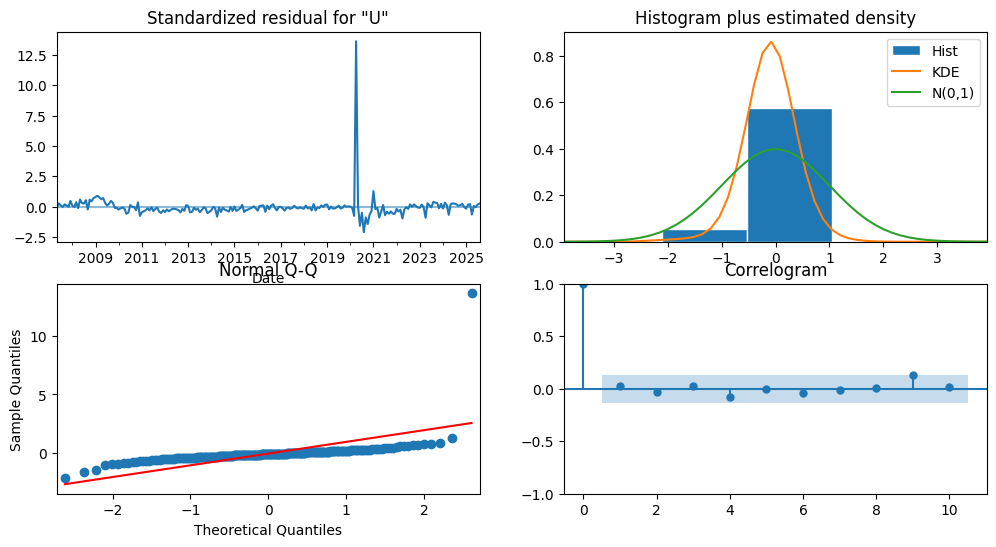

In [30]:
fit_us.plot_diagnostics(figsize=(12,6))
plt.show()

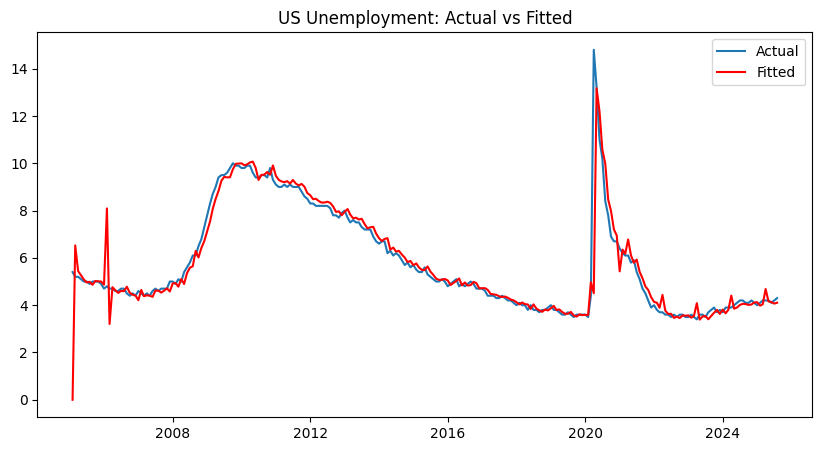

In [31]:
plt.figure(figsize=(10,5))
plt.plot(y_us, label='Actual')
plt.plot(fit_us.fittedvalues, color='red', label='Fitted')
plt.title('US Unemployment: Actual vs Fitted')
plt.legend()
plt.show()

Out-of-sample MAE: 0.56
Out-of-sample MAPE: 14.12%


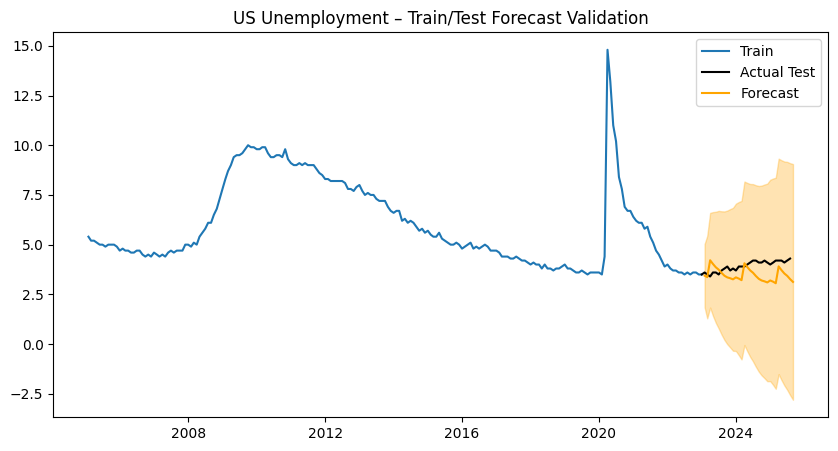

In [32]:
split_date = '2023-01-01'
train_y = y_us.loc[:split_date]
test_y = y_us.loc[split_date:]
train_exog = exog_us.loc[:split_date]
test_exog = exog_us.loc[split_date:]

# Refit on train
model_cv = SARIMAX(train_y,
                   exog=train_exog,
                   order=(1,1,1),
                   seasonal_order=(0,1,1,12),
                   enforce_stationarity=False,
                   enforce_invertibility=False)
fit_cv = model_cv.fit(disp=False)

# Forecast into test period
forecast_cv = fit_cv.get_forecast(steps=len(test_y), exog=test_exog)
pred_mean = forecast_cv.predicted_mean
conf_int = forecast_cv.conf_int()

# Compute errors
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
mae = mean_absolute_error(test_y, pred_mean)
mape = mean_absolute_percentage_error(test_y, pred_mean)

print(f"Out-of-sample MAE: {mae:.2f}")
print(f"Out-of-sample MAPE: {mape:.2%}")

# Plot
plt.figure(figsize=(10,5))
plt.plot(train_y, label='Train')
plt.plot(test_y, label='Actual Test', color='black')
plt.plot(pred_mean, label='Forecast', color='orange')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='orange', alpha=0.3)
plt.legend()
plt.title('US Unemployment – Train/Test Forecast Validation')
plt.show()

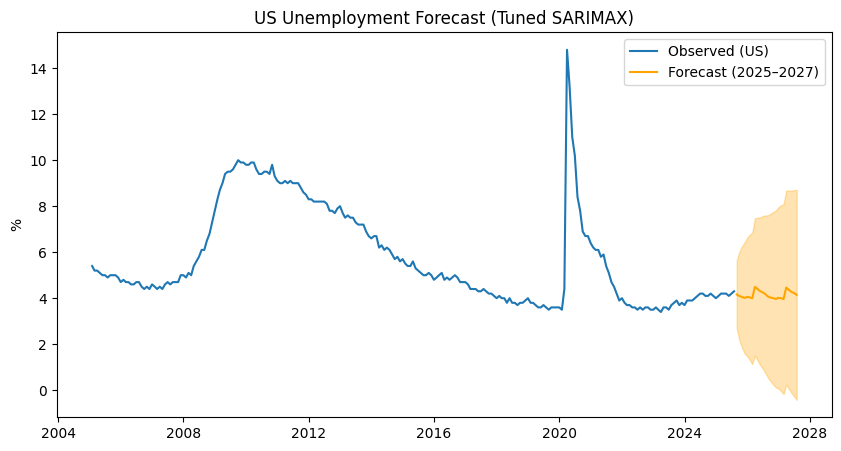

In [33]:
future_dates = pd.date_range('2025-09-01', periods=24, freq='MS')
future_exog = pd.DataFrame({'Crisis_2008': [0]*24, 'Crisis_2020': [0]*24}, index=future_dates)

us_forecast = fit_us.get_forecast(steps=24, exog=future_exog)
us_forecast_mean = us_forecast.predicted_mean
us_conf_int = us_forecast.conf_int()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_us, label='Observed (US)')
plt.plot(us_forecast_mean, color='orange', label='Forecast (2025–2027)')
plt.fill_between(us_conf_int.index, us_conf_int.iloc[:,0], us_conf_int.iloc[:,1], color='orange', alpha=0.3)
plt.title('US Unemployment Forecast (Tuned SARIMAX)')
plt.ylabel('%')
plt.legend()
plt.show()

In [34]:
final_combined = final_combined.asfreq('MS')
y_cpi = final_combined['CPI'].dropna()
exog_cpi = final_combined.loc[y_cpi.index, ['Crisis_2008', 'Crisis_2020']]

In [35]:
best_params_cpi, results_cpi = tune_sarimax(y_cpi, exog_cpi)
order_cpi, seas_cpi = best_params_cpi

✅ Best model: SARIMAX(1, 1, 2)x(0, 1, 1)12, AIC=461.79


In [36]:
model_cpi = SARIMAX(y_cpi,
                    exog=exog_cpi,
                    order=order_cpi,
                    seasonal_order=seas_cpi + (12,),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
fit_cpi = model_cpi.fit(disp=False, maxiter=1000)
print(fit_cpi.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  CPI   No. Observations:                  247
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -223.897
Date:                              Thu, 16 Oct 2025   AIC                            461.794
Time:                                      17:00:20   BIC                            485.518
Sample:                                  02-01-2005   HQIC                           471.375
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Crisis_2008     0.1851      0.378      0.490      0.624      -0.556       0.926
Crisis_2020     

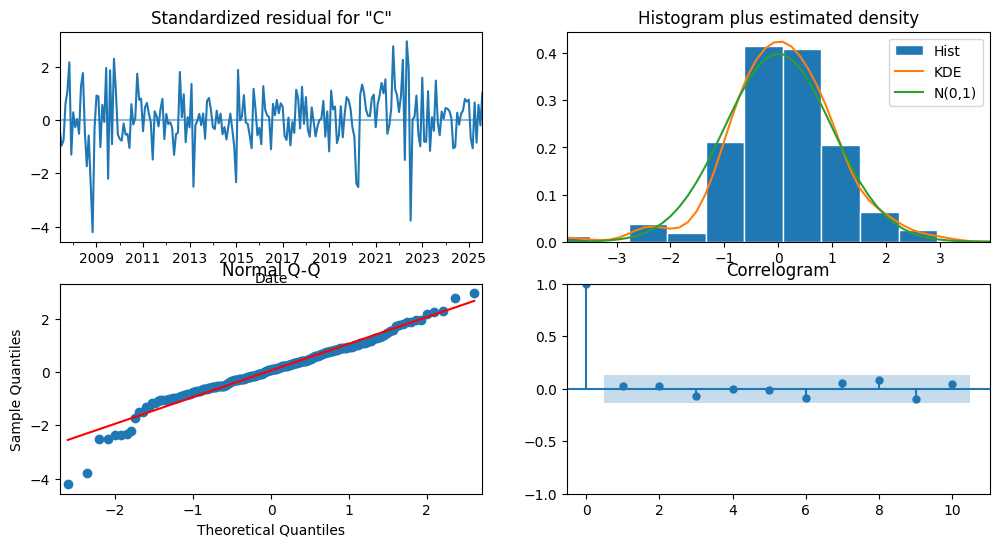

In [37]:
fit_cpi.plot_diagnostics(figsize=(12,6))
plt.show()

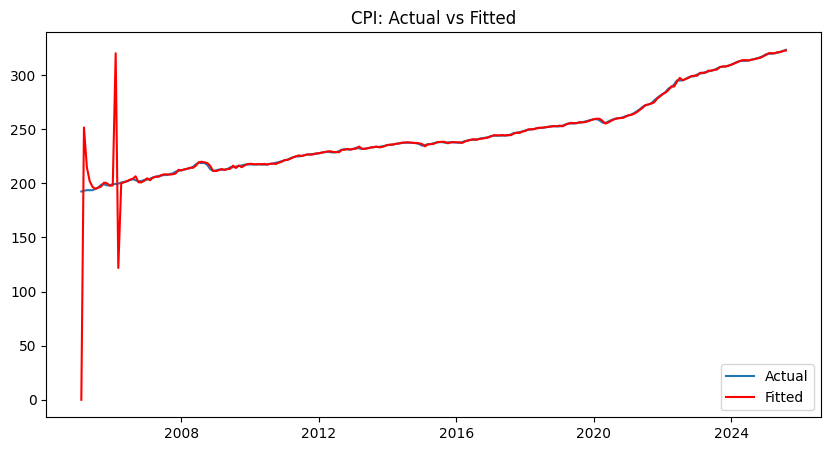

In [38]:
plt.figure(figsize=(10,5))
plt.plot(y_cpi, label='Actual')
plt.plot(fit_cpi.fittedvalues, color='red', label='Fitted')
plt.title('CPI: Actual vs Fitted')
plt.legend()
plt.show()

Out-of-sample MAE: 3.18
Out-of-sample MAPE: 1.02%


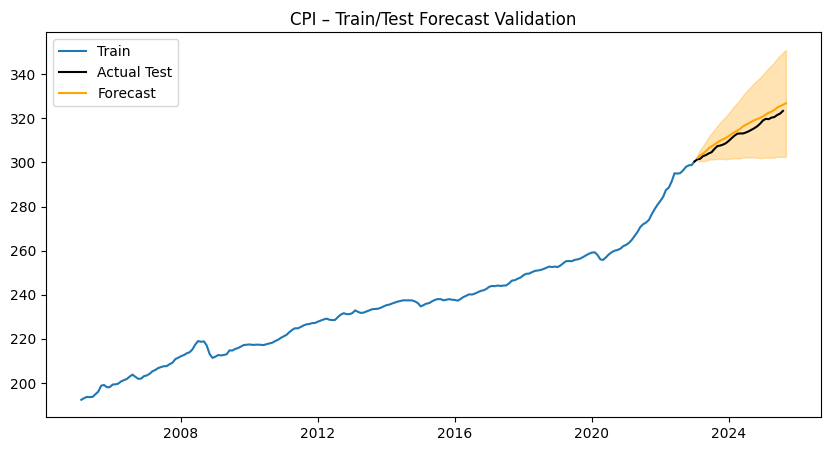

In [39]:
split_date = '2023-01-01'
train_y = y_cpi.loc[:split_date]
test_y = y_cpi.loc[split_date:]
train_exog = exog_cpi.loc[:split_date]
test_exog = exog_cpi.loc[split_date:]

# Refit on train
model_cv = SARIMAX(train_y,
                   exog=train_exog,
                   order=(1,1,2),
                   seasonal_order=(0,1,1,12),
                   enforce_stationarity=False,
                   enforce_invertibility=False)
fit_cv = model_cv.fit(disp=False)

# Forecast into test period
forecast_cv = fit_cv.get_forecast(steps=len(test_y), exog=test_exog)
pred_mean = forecast_cv.predicted_mean
conf_int = forecast_cv.conf_int()

# Compute errors
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
mae = mean_absolute_error(test_y, pred_mean)
mape = mean_absolute_percentage_error(test_y, pred_mean)

print(f"Out-of-sample MAE: {mae:.2f}")
print(f"Out-of-sample MAPE: {mape:.2%}")

# Plot
plt.figure(figsize=(10,5))
plt.plot(train_y, label='Train')
plt.plot(test_y, label='Actual Test', color='black')
plt.plot(pred_mean, label='Forecast', color='orange')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='orange', alpha=0.3)
plt.legend()
plt.title('CPI – Train/Test Forecast Validation')
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np


Inflation_MoM (derived from CPI forecast):
  MAE  = 0.130
  MAPE = 5.077


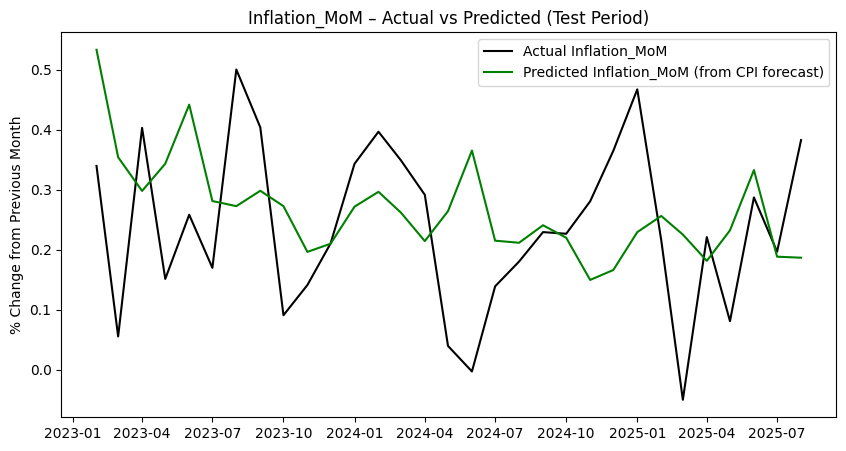

In [41]:
# Compute actual Inflation_MoM from true CPI
actual_infl_test = 100 * test_y.pct_change().dropna()

# Predicted Inflation_MoM (using last train + forecasted CPI)
cpi_for_mom = pd.concat([train_y.iloc[[-1]], pred_mean])
pred_infl_test = 100 * cpi_for_mom.pct_change().iloc[1:]

# Align predicted with actual
pred_infl_test = pred_infl_test.loc[actual_infl_test.index]

# Compute errors
mae_infl = mean_absolute_error(actual_infl_test, pred_infl_test)
mape_infl = mean_absolute_percentage_error(actual_infl_test, pred_infl_test)

print(f"\nInflation_MoM (derived from CPI forecast):")
print(f"  MAE  = {mae_infl:.3f}")
print(f"  MAPE = {mape_infl:.3f}")

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(actual_infl_test, label='Actual Inflation_MoM', color='black')
plt.plot(pred_infl_test, label='Predicted Inflation_MoM (from CPI forecast)', color='green')
plt.title('Inflation_MoM – Actual vs Predicted (Test Period)')
plt.ylabel('% Change from Previous Month')
plt.legend()
plt.show()

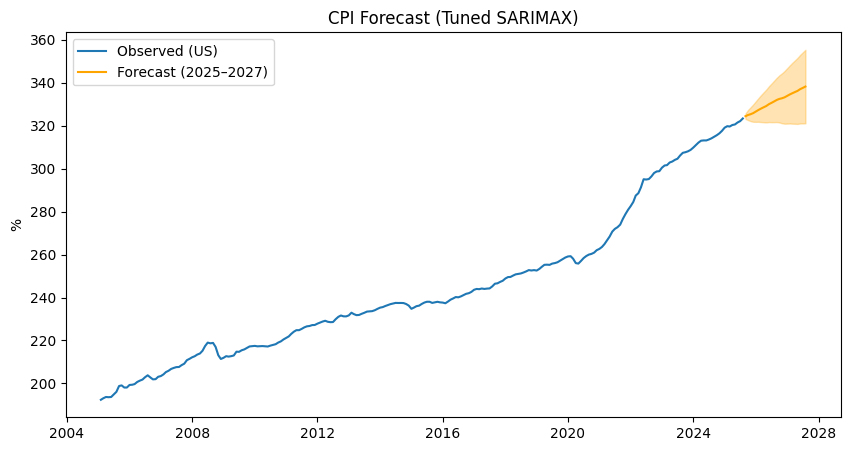

In [42]:
future_dates = pd.date_range('2025-09-01', periods=24, freq='MS')
future_exog = pd.DataFrame({'Crisis_2008': [0]*24, 'Crisis_2020': [0]*24}, index=future_dates)

cpi_forecast = fit_cpi.get_forecast(steps=24, exog=future_exog)
cpi_forecast_mean = cpi_forecast.predicted_mean
cpi_conf_int = cpi_forecast.conf_int()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_cpi, label='Observed (US)')
plt.plot(cpi_forecast_mean, color='orange', label='Forecast (2025–2027)')
plt.fill_between(cpi_conf_int.index, cpi_conf_int.iloc[:,0], cpi_conf_int.iloc[:,1], color='orange', alpha=0.3)
plt.title('CPI Forecast (Tuned SARIMAX)')
plt.ylabel('%')
plt.legend()
plt.show()


📈 Forecasted Inflation (Month-over-Month %):
2025-09-01    0.327089
2025-10-01    0.172071
2025-11-01    0.117758
2025-12-01    0.157063
2026-01-01    0.229809
Freq: MS, Name: Forecast_Inflation_MoM, dtype: float64


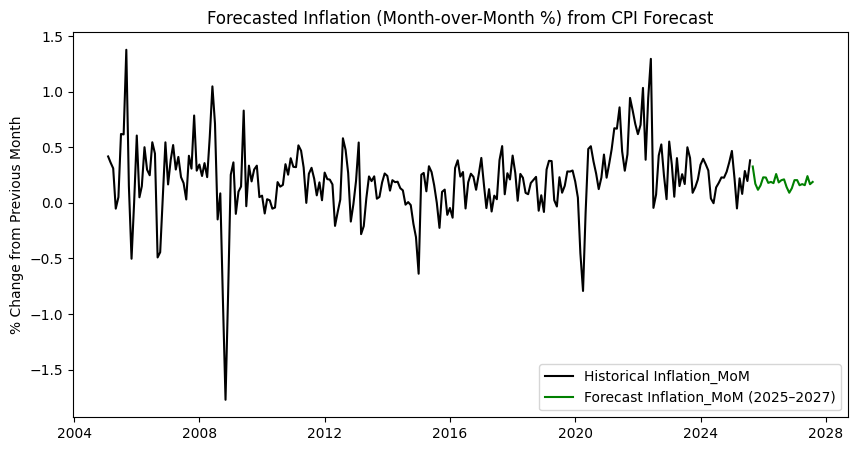


✅ Saved: Inflation_Forecast_2025_2027.xlsx


In [43]:

# Derive Inflation_MoM (%) from CPI forecast

# Combine last actual CPI with forecasted CPI
# This ensures the first MoM calculation (Sep 2025) has Aug 2025 as baseline.
cpi_full = pd.concat([y_cpi.iloc[[-1]], cpi_forecast_mean])

# Calculate month-over-month inflation (%)
inflation_forecast = 100 * cpi_full.pct_change().iloc[1:]   # drop first NaN
inflation_forecast.name = 'Forecast_Inflation_MoM'

# Display first few rows
print("\n📈 Forecasted Inflation (Month-over-Month %):")
print(inflation_forecast.head())

# Plot Inflation Forecast
plt.figure(figsize=(10,5))
plt.plot(final_combined['Inflation_MoM'], label='Historical Inflation_MoM', color='black')
plt.plot(inflation_forecast, label='Forecast Inflation_MoM (2025–2027)', color='green')
plt.title('Forecasted Inflation (Month-over-Month %) from CPI Forecast')
plt.ylabel('% Change from Previous Month')
plt.legend()
plt.show()

# Save to Excel
out = pd.concat([cpi_forecast_mean, inflation_forecast], axis=1)
out.columns = ['Forecast_CPI', 'Forecast_Inflation_MoM']
out.to_excel('Inflation_Forecast_2025_2027.xlsx', index_label='Date')

print("\n✅ Saved: Inflation_Forecast_2025_2027.xlsx")

In [44]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================================
# Helper: SARIMAX tuning (AIC-based)
# ==========================================================
def tune_sarimax(y, exog=None, 
                 p=range(0,3), d=range(1,2), q=range(0,3),
                 P=range(0,2), D=range(1,2), Q=range(0,2), s=12):
    best_aic = np.inf
    best_params = None
    for order in itertools.product(p, d, q):
        for seas in itertools.product(P, D, Q):
            try:
                model = SARIMAX(y, exog=exog, 
                                order=order, 
                                seasonal_order=seas + (s,),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                fit = model.fit(disp=False, maxiter=500)
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_params = (order, seas)
            except:
                continue
    return best_params, best_aic

In [ ]:

# Prepare data
final_combined = final_combined.asfreq('MS')

# Define target metros (exclude US, Inflation, CPI, etc.)
metros = [col for col in final_combined.columns 
           if col not in ['US','CPI','Inflation_MoM','Crisis_2008','Crisis_2020']]

# Historical macro regressors
macro_exog_hist = final_combined[['US','Inflation_MoM','Crisis_2008','Crisis_2020']]

# Combine macro forecasts (US + Inflation)
macro_forecast = pd.concat([us_forecast_mean, inflation_forecast], axis=1)
macro_forecast.columns = ['US','Inflation_MoM']
# Add dummy crisis columns (0 for future)
macro_forecast['Crisis_2008'] = 0
macro_forecast['Crisis_2020'] = 0


==================== Minneapolis ====================


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best model for Minneapolis: SARIMAX(0, 1, 1)x(0, 1, 1)12 (AIC=98.48)
Validation → MAE: 0.453, RMSE: 0.420


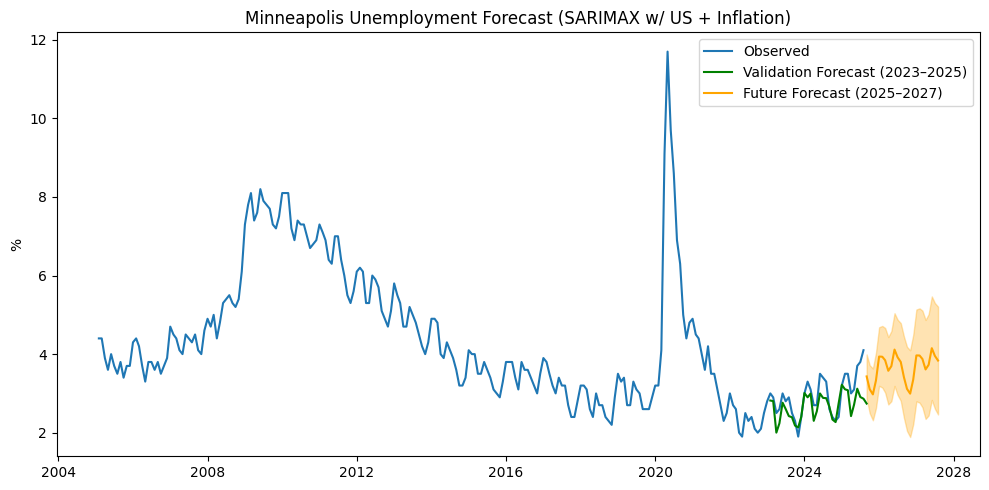


==================== Dallas ====================
Best model for Dallas: SARIMAX(2, 1, 2)x(0, 1, 1)12 (AIC=-133.64)
Validation → MAE: 0.251, RMSE: 0.225


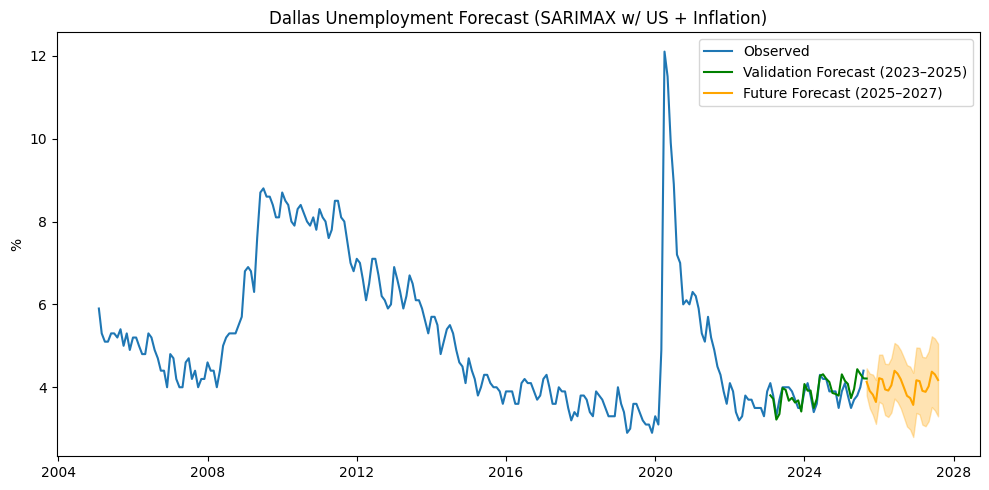


==================== Phoenix ====================
Best model for Phoenix: SARIMAX(0, 1, 1)x(1, 1, 1)12 (AIC=-144.03)
Validation → MAE: 0.261, RMSE: 0.255


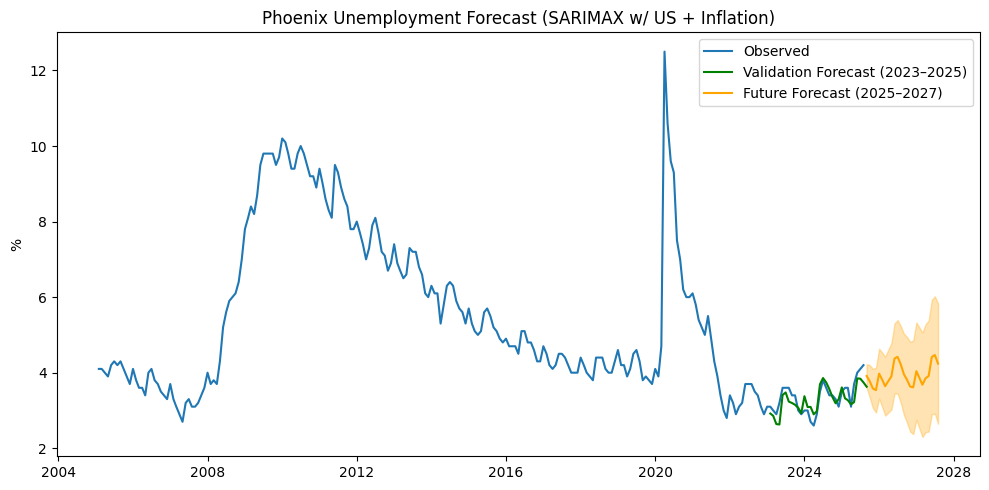


==================== Chicago ====================
Best model for Chicago: SARIMAX(2, 1, 2)x(0, 1, 1)12 (AIC=-62.51)
Validation → MAE: 0.542, RMSE: 0.542


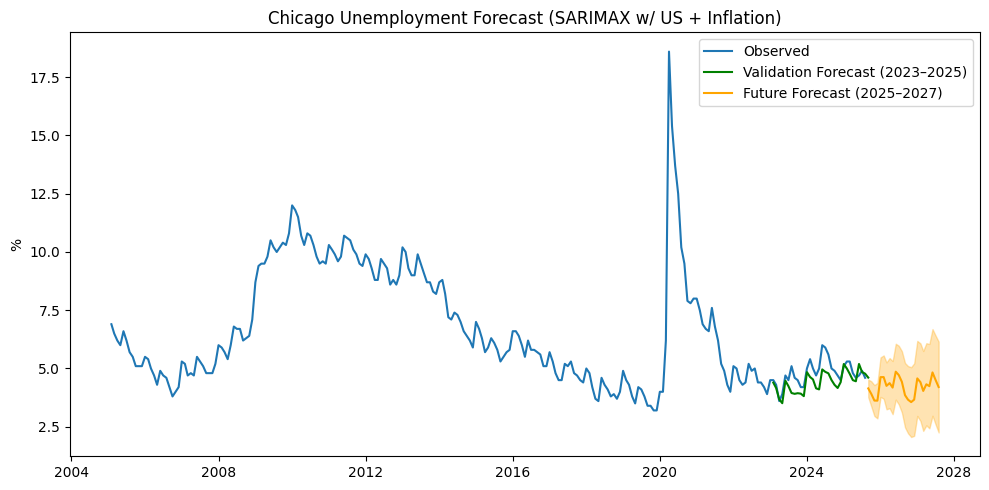


==================== Atlanta ====================


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best model for Atlanta: SARIMAX(1, 1, 0)x(1, 1, 1)12 (AIC=-256.84)
Validation → MAE: 0.230, RMSE: 0.164


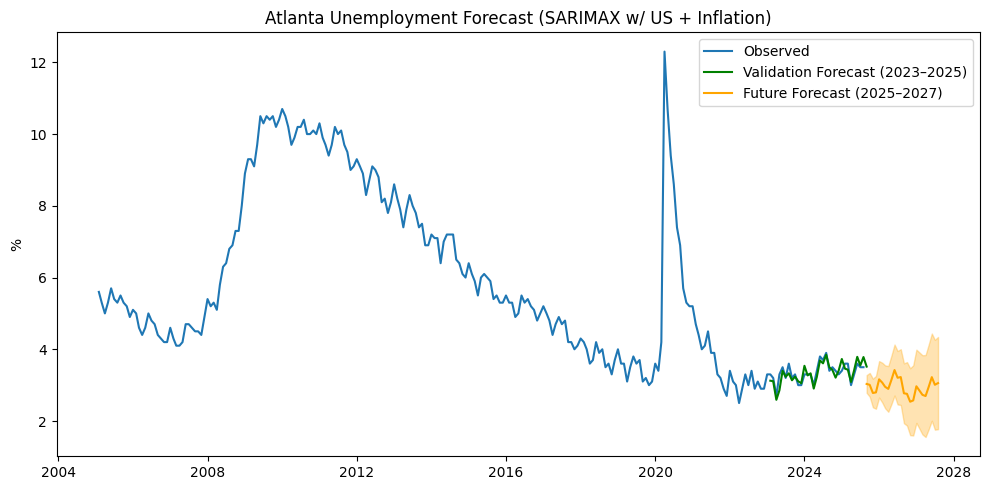


==================== Houston ====================


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best model for Houston: SARIMAX(2, 1, 2)x(1, 1, 1)12 (AIC=-114.26)
Validation → MAE: 0.324, RMSE: 0.334


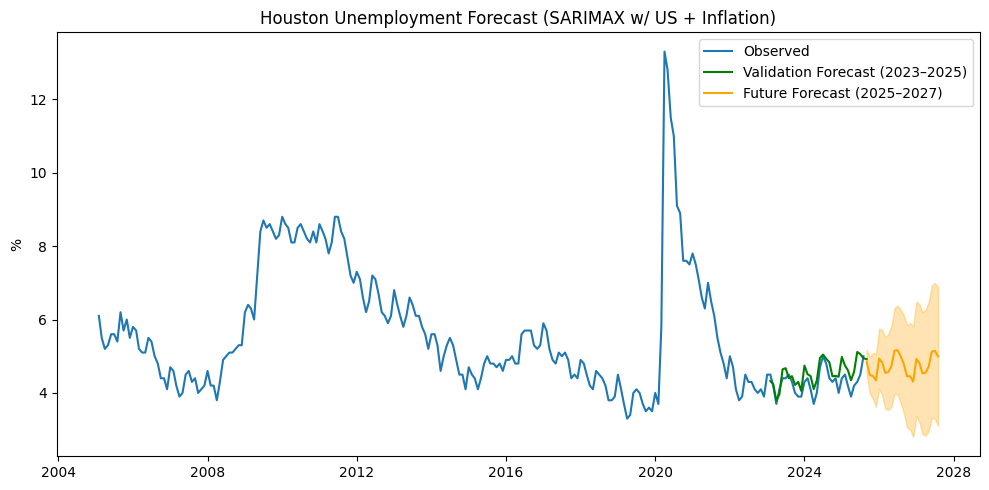

In [ ]:

# Loop over metros
forecast_dict = {}

for city in metros:
    print(f"\n==================== {city} ====================")
    y = final_combined[city].dropna()
    exog = macro_exog_hist.loc[y.index]

    # In-sample AIC tuning

    best_params, best_aic = tune_sarimax(y, exog[['US','Inflation_MoM','Crisis_2008','Crisis_2020']])
    order, seas = best_params
    print(f"Best model for {city}: SARIMAX{order}x{seas}12 (AIC={best_aic:.2f})")

    # Validation Split (Train/Test)
    split_date = '2023-01-01'
    y_train = y.loc[:split_date]
    y_valid = y.loc[split_date:]
    X_train = exog.loc[:split_date]
    X_valid = exog.loc[split_date:]

    model = SARIMAX(y_train, exog=X_train,
                    order=order, seasonal_order=seas + (12,),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=1000)

    # Forecast on validation period
    fc_valid = fit.get_forecast(steps=len(y_valid), exog=X_valid)
    pred = fc_valid.predicted_mean
    conf = fc_valid.conf_int()

    # Validation metrics
    mae = mean_absolute_error(y_valid, pred)
    rmse = np.sqrt(np.mean((y_valid - pred) ** 2))
    print(f"Validation → MAE: {mae:.3f}, RMSE: {rmse:.3f}")

    
    # Refit full model & forecast future
    model_full = SARIMAX(y, exog=exog,
                         order=order, seasonal_order=seas + (12,),
                         enforce_stationarity=False, enforce_invertibility=False)
    fit_full = model_full.fit(disp=False, maxiter=1000)

    fc_future = fit_full.get_forecast(steps=24, exog=macro_forecast)
    pred_future = fc_future.predicted_mean
    conf_future = fc_future.conf_int()

    # Store forecasts
    forecast_dict[city] = pd.DataFrame({
        'Forecast': pred_future,
        'Lower_CI': conf_future.iloc[:,0],
        'Upper_CI': conf_future.iloc[:,1]
    })

    # Visualization (optional)
    plt.figure(figsize=(10,5))
    plt.plot(y, label='Observed')
    plt.plot(pred, color='green', label='Validation Forecast (2023–2025)')
    plt.plot(pred_future, color='orange', label='Future Forecast (2025–2027)')
    plt.fill_between(conf_future.index,
                     conf_future.iloc[:,0],
                     conf_future.iloc[:,1],
                     color='orange', alpha=0.3)
    plt.title(f"{city} Unemployment Forecast (SARIMAX w/ US + Inflation)")
    plt.ylabel('%')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:

# Combine all metro forecasts
combined_forecasts = pd.concat(
    {city: df['Forecast'] for city, df in forecast_dict.items()},
    axis=1
)

# Save to Excel
combined_forecasts.to_excel('Metro_Unemployment_Forecasts_2025_2027.xlsx', index_label='Date')

print("\n✅ All metro forecasts saved: Metro_Unemployment_Forecasts_2025_2027.xlsx")


✅ All metro forecasts saved: Metro_Unemployment_Forecasts_2025_2027.xlsx
